# Temperature Effects Analysis

This notebook examines how temperature (0.2 vs 0.8) affects the variance of selfish choices at high D-levels.

**Key Question**: Does higher temperature increase behavioral variance, particularly for high-D (selfish) personas?

**Reviewer Comment**: "Although temperature had a minimal impact, a more detailed breakdown of how it affected the variance of 'selfish' choices at high D-levels would be insightful."

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'

# Colors
COLOR_LOW_TEMP = '#3498DB'   # Blue - Temperature 0.2
COLOR_HIGH_TEMP = '#E74C3C'  # Red - Temperature 0.8
COLOR_HUMAN = '#2ECC71'      # Green - Human benchmark
ALPHA_FILL = 0.20

## 1. Load and Prepare Data

In [3]:
# Load data
df = pd.read_csv('data/aidata.csv')

# Map D-levels to numeric
d_map = {'Low': 1, 'Low-Moderate': 2, 'Moderate': 3, 'Moderate-High': 4, 'High': 5}
df['d_num'] = df['d'].map(d_map)

# Create selfish variable for proposers (selfish = not prosocial)
df['selfish'] = 1 - df['prosocial']

# Separate by role
prop = df[df['role'] == 'proposer'].copy()
resp = df[df['role'] == 'responder'].copy()

print(f"Total observations: {len(df):,}")
print(f"Proposer observations: {len(prop):,}")
print(f"Responder observations: {len(resp):,}")
print(f"\nTemperatures: {sorted(df['temperature'].unique())}")
print(f"Models: {len(df['model'].unique())}")

Total observations: 339,956
Proposer observations: 169,981
Responder observations: 169,975

Temperatures: [np.float64(0.2), np.float64(0.8)]
Models: 17


In [4]:
# Check balance
print("Temperature x D-Level Distribution (Proposers)")
print("="*50)
print(pd.crosstab(prop['temperature'], prop['d']))

Temperature x D-Level Distribution (Proposers)
d             High    Low  Low-Moderate  Moderate  Moderate-High
temperature                                                     
0.2          17000  17000         17000     17000          17000
0.8          17000  16994         16995     16995          16997


## 2. Overall Temperature Effects

In [5]:
# Overall selfish rate by temperature (Proposers)
print("PROPOSER: Selfish Rate by Temperature")
print("="*50)
overall = prop.groupby('temperature')['selfish'].agg(['mean', 'std', 'var', 'count'])
overall['se'] = overall['std'] / np.sqrt(overall['count'])
print(overall.round(4))

# Statistical test
lt = prop[prop['temperature'] == 0.2]['selfish']
ht = prop[prop['temperature'] == 0.8]['selfish']
stat, p = stats.levene(lt, ht)
print(f"\nLevene's test for variance equality: W = {stat:.2f}, p = {p:.6f}")

PROPOSER: Selfish Rate by Temperature
               mean     std     var  count      se
temperature                                       
0.2          0.5082  0.4999  0.2499  85000  0.0017
0.8          0.5101  0.4999  0.2499  84981  0.0017

Levene's test for variance equality: W = 0.61, p = 0.435658


## 3. Temperature Effects by D-Level

In [6]:
# Compute statistics by D-level and temperature
results = []
d_labels = {1: 'D1 (Low)', 2: 'D2 (Low-Mod)', 3: 'D3 (Moderate)', 
            4: 'D4 (Mod-High)', 5: 'D5 (High)'}

for d_level in [1, 2, 3, 4, 5]:
    subset = prop[prop['d_num'] == d_level]
    lt = subset[subset['temperature'] == 0.2]['selfish']
    ht = subset[subset['temperature'] == 0.8]['selfish']
    
    # Statistics
    mean_diff = ht.mean() - lt.mean()
    var_ratio = ht.var() / lt.var() if lt.var() > 0 else np.nan
    
    # Tests
    cont = pd.crosstab(subset['temperature'], subset['selfish'])
    chi2, p_chi = stats.chi2_contingency(cont)[:2]
    lev_stat, p_lev = stats.levene(lt, ht)
    
    results.append({
        'D-Level': d_labels[d_level],
        'Mean (0.2)': lt.mean(),
        'Mean (0.8)': ht.mean(),
        'Δ Mean': mean_diff,
        'Var (0.2)': lt.var(),
        'Var (0.8)': ht.var(),
        'Var Ratio': var_ratio,
        'Levene W': lev_stat,
        'p (var)': p_lev,
        'χ²': chi2,
        'p (mean)': p_chi
    })

results_df = pd.DataFrame(results)
print("Temperature Effects by D-Level (Proposers)")
print("="*80)
print(results_df.round(4).to_string(index=False))

Temperature Effects by D-Level (Proposers)
      D-Level  Mean (0.2)  Mean (0.8)  Δ Mean  Var (0.2)  Var (0.8)  Var Ratio  Levene W  p (var)      χ²  p (mean)
     D1 (Low)      0.0965      0.0786 -0.0179     0.0872     0.0724     0.8305   34.1823   0.0000 33.9260    0.0000
 D2 (Low-Mod)      0.2257      0.2277  0.0019     0.1748     0.1758     1.0061    0.1842   0.6678  0.1733    0.6772
D3 (Moderate)      0.5799      0.5763 -0.0036     0.2436     0.2442     1.0023    0.4504   0.5022  0.4358    0.5092
D4 (Mod-High)      0.8135      0.8284  0.0149     0.1517     0.1422     0.9369   12.8585   0.0003 12.7531    0.0004
    D5 (High)      0.8253      0.8392  0.0139     0.1442     0.1349     0.9357   11.8374   0.0006 11.7344    0.0006


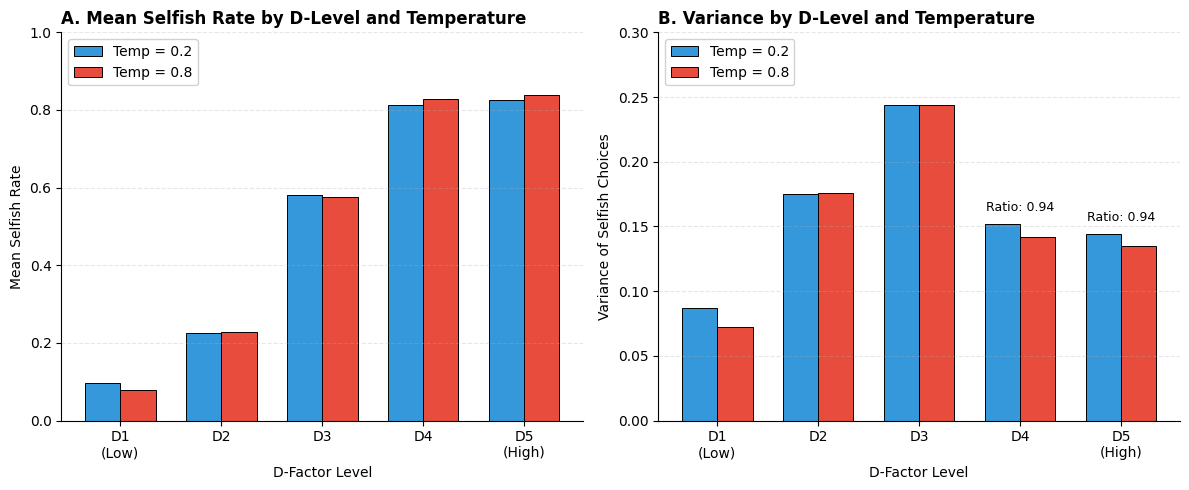

Saved: Figures/temperature_effects_by_dlevel.png and .pdf


In [9]:
# Visualization: Variance by D-level and Temperature
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

d_levels = [1, 2, 3, 4, 5]
d_labels_short = ['D1\n(Low)', 'D2', 'D3', 'D4', 'D5\n(High)']

# Panel A: Mean selfish rate
ax1 = axes[0]
x = np.arange(len(d_levels))
width = 0.35

means_02 = [results_df.loc[i, 'Mean (0.2)'] for i in range(5)]
means_08 = [results_df.loc[i, 'Mean (0.8)'] for i in range(5)]

bars1 = ax1.bar(x - width/2, means_02, width, label='Temp = 0.2', 
                color=COLOR_LOW_TEMP, edgecolor='black', linewidth=0.7)
bars2 = ax1.bar(x + width/2, means_08, width, label='Temp = 0.8', 
                color=COLOR_HIGH_TEMP, edgecolor='black', linewidth=0.7)

ax1.set_xlabel('D-Factor Level', fontweight='medium')
ax1.set_ylabel('Mean Selfish Rate', fontweight='medium')
ax1.set_title('A. Mean Selfish Rate by D-Level and Temperature', fontweight='bold', loc='left')
ax1.set_xticks(x)
ax1.set_xticklabels(d_labels_short)
ax1.legend(loc='upper left', framealpha=0.9)
ax1.set_ylim(0, 1.0)
ax1.yaxis.grid(True, alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Panel B: Variance
ax2 = axes[1]

vars_02 = [results_df.loc[i, 'Var (0.2)'] for i in range(5)]
vars_08 = [results_df.loc[i, 'Var (0.8)'] for i in range(5)]

bars1 = ax2.bar(x - width/2, vars_02, width, label='Temp = 0.2', 
                color=COLOR_LOW_TEMP, edgecolor='black', linewidth=0.7)
bars2 = ax2.bar(x + width/2, vars_08, width, label='Temp = 0.8', 
                color=COLOR_HIGH_TEMP, edgecolor='black', linewidth=0.7)

ax2.set_xlabel('D-Factor Level', fontweight='medium')
ax2.set_ylabel('Variance of Selfish Choices', fontweight='medium')
ax2.set_title('B. Variance by D-Level and Temperature', fontweight='bold', loc='left')
ax2.set_xticks(x)
ax2.set_xticklabels(d_labels_short)
ax2.legend(loc='upper left', framealpha=0.9)
ax2.set_ylim(0, 0.30)
ax2.yaxis.grid(True, alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Add variance ratio annotations for high D
for i in [3, 4]:  # D4 and D5
    ratio = vars_08[i] / vars_02[i]
    y_pos = max(vars_02[i], vars_08[i]) + 0.01
    ax2.annotate(f'Ratio: {ratio:.2f}', xy=(i, y_pos), ha='center', fontsize=9)

plt.tight_layout()
#plt.savefig('temperature_effects_by_dlevel.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 4. Focus on High D-Levels (D4 & D5)

In [10]:
# Detailed analysis at high D-levels
high_d = prop[prop['d_num'] >= 4]

print("HIGH D-LEVEL ANALYSIS (D4 & D5 Combined)")
print("="*60)

lt = high_d[high_d['temperature'] == 0.2]['selfish']
ht = high_d[high_d['temperature'] == 0.8]['selfish']

print(f"\nTemperature 0.2:")
print(f"  N = {len(lt):,}")
print(f"  Mean = {lt.mean():.4f} (SE = {lt.std()/np.sqrt(len(lt)):.4f})")
print(f"  SD = {lt.std():.4f}")
print(f"  Variance = {lt.var():.4f}")

print(f"\nTemperature 0.8:")
print(f"  N = {len(ht):,}")
print(f"  Mean = {ht.mean():.4f} (SE = {ht.std()/np.sqrt(len(ht)):.4f})")
print(f"  SD = {ht.std():.4f}")
print(f"  Variance = {ht.var():.4f}")

# Comparisons
mean_diff = ht.mean() - lt.mean()
var_ratio = ht.var() / lt.var()

print(f"\nComparisons:")
print(f"  Mean difference (0.8 - 0.2): {mean_diff:+.4f}")
print(f"  Variance ratio (0.8 / 0.2): {var_ratio:.4f}")

# Statistical tests
cont = pd.crosstab(high_d['temperature'], high_d['selfish'])
chi2, p_chi = stats.chi2_contingency(cont)[:2]
lev_stat, p_lev = stats.levene(lt, ht)

print(f"\nStatistical Tests:")
print(f"  Chi-square (proportions): χ² = {chi2:.2f}, p = {p_chi:.6f}")
print(f"  Levene (variance): W = {lev_stat:.2f}, p = {p_lev:.6f}")

# Effect size
pooled_std = np.sqrt((lt.var() + ht.var()) / 2)
cohens_d = mean_diff / pooled_std
print(f"\nEffect Size:")
print(f"  Cohen's d = {cohens_d:.4f} (negligible: |d| < 0.2)")

HIGH D-LEVEL ANALYSIS (D4 & D5 Combined)

Temperature 0.2:
  N = 34,000
  Mean = 0.8194 (SE = 0.0021)
  SD = 0.3847
  Variance = 0.1480

Temperature 0.8:
  N = 33,997
  Mean = 0.8338 (SE = 0.0020)
  SD = 0.3723
  Variance = 0.1386

Comparisons:
  Mean difference (0.8 - 0.2): +0.0144
  Variance ratio (0.8 / 0.2): 0.9363

Statistical Tests:
  Chi-square (proportions): χ² = 24.58, p = 0.000001
  Levene (variance): W = 24.69, p = 0.000001

Effect Size:
  Cohen's d = 0.0381 (negligible: |d| < 0.2)


In [11]:
# Separate analysis for D4 and D5
print("\nSEPARATE ANALYSIS BY D-LEVEL")
print("="*60)

for d_level, d_name in [(4, 'D4 (Moderate-High)'), (5, 'D5 (High)')]:
    subset = prop[prop['d_num'] == d_level]
    lt = subset[subset['temperature'] == 0.2]['selfish']
    ht = subset[subset['temperature'] == 0.8]['selfish']
    
    print(f"\n{d_name}:")
    print(f"  Temp 0.2: Mean={lt.mean():.4f}, Var={lt.var():.4f}, N={len(lt)}")
    print(f"  Temp 0.8: Mean={ht.mean():.4f}, Var={ht.var():.4f}, N={len(ht)}")
    print(f"  Mean diff: {ht.mean() - lt.mean():+.4f}")
    print(f"  Var ratio: {ht.var() / lt.var():.4f}")
    
    # Interpretation
    if ht.var() < lt.var():
        print(f"  → Higher temperature REDUCED variance")
    else:
        print(f"  → Higher temperature INCREASED variance")


SEPARATE ANALYSIS BY D-LEVEL

D4 (Moderate-High):
  Temp 0.2: Mean=0.8135, Var=0.1517, N=17000
  Temp 0.8: Mean=0.8284, Var=0.1422, N=16997
  Mean diff: +0.0149
  Var ratio: 0.9369
  → Higher temperature REDUCED variance

D5 (High):
  Temp 0.2: Mean=0.8253, Var=0.1442, N=17000
  Temp 0.8: Mean=0.8392, Var=0.1349, N=17000
  Mean diff: +0.0139
  Var ratio: 0.9357
  → Higher temperature REDUCED variance


## 5. Per-Model Analysis: Ceiling Effects

In [12]:
# Identify models with ceiling effects vs. behavioral variance
high_d = prop[prop['d_num'] >= 4]

model_var = high_d.groupby('model')['selfish'].var()
variable_models = model_var[model_var > 0.01].index.tolist()
ceiling_models = model_var[model_var <= 0.01].index.tolist()

print("MODEL CLASSIFICATION BY BEHAVIORAL VARIANCE AT HIGH D")
print("="*60)
print(f"\nModels with behavioral variance (var > 0.01): {len(variable_models)}")
for m in variable_models:
    print(f"  - {m}: var = {model_var[m]:.4f}")

print(f"\nModels at ceiling (var <= 0.01): {len(ceiling_models)}")
for m in ceiling_models:
    print(f"  - {m}: var = {model_var[m]:.4f}")

MODEL CLASSIFICATION BY BEHAVIORAL VARIANCE AT HIGH D

Models with behavioral variance (var > 0.01): 5
  - deepseek_1.5b: var = 0.2031
  - deepseek_7b: var = 0.1274
  - dolphin3: var = 0.1148
  - llama2uncensored_7b: var = 0.2391
  - llama3.2: var = 0.1491

Models at ceiling (var <= 0.01): 12
  - gemma3_12b: var = 0.0000
  - gemma3_1b: var = 0.0000
  - gemma3_4b: var = 0.0000
  - gemma3n_e2b: var = 0.0000
  - gemma3n_e4b: var = 0.0000
  - gptoss_20b: var = 0.0005
  - granite3.3_8b: var = 0.0000
  - llama3.1: var = 0.0000
  - mistral: var = 0.0000
  - phi4: var = 0.0000
  - qwen2.5: var = 0.0000
  - qwen3: var = 0.0000


In [13]:
# Detailed per-model analysis
print("\nPER-MODEL TEMPERATURE EFFECTS AT HIGH D-LEVELS")
print("="*80)

model_results = []
for model in sorted(prop['model'].unique()):
    subset = high_d[high_d['model'] == model]
    lt = subset[subset['temperature'] == 0.2]['selfish']
    ht = subset[subset['temperature'] == 0.8]['selfish']
    
    if len(lt) >= 50 and len(ht) >= 50:
        var_ratio = ht.var() / lt.var() if lt.var() > 0.001 else np.nan
        
        try:
            lev_stat, p_lev = stats.levene(lt, ht)
        except:
            lev_stat, p_lev = np.nan, np.nan
        
        model_results.append({
            'Model': model,
            'Mean (0.2)': lt.mean(),
            'Mean (0.8)': ht.mean(),
            'Var (0.2)': lt.var(),
            'Var (0.8)': ht.var(),
            'Var Ratio': var_ratio,
            'Levene p': p_lev,
            'Type': 'Variable' if model in variable_models else 'Ceiling'
        })

model_df = pd.DataFrame(model_results)
print(model_df.round(4).to_string(index=False))


PER-MODEL TEMPERATURE EFFECTS AT HIGH D-LEVELS
              Model  Mean (0.2)  Mean (0.8)  Var (0.2)  Var (0.8)  Var Ratio  Levene p     Type
      deepseek_1.5b      0.2665      0.3000     0.1956     0.2101     1.0743    0.0187 Variable
        deepseek_7b      0.8760      0.8245     0.1087     0.1448     1.3321    0.0000 Variable
           dolphin3      0.0110      0.2535     0.0109     0.1893    17.3948    0.0000 Variable
         gemma3_12b      1.0000      1.0000     0.0000     0.0000        NaN       NaN  Ceiling
          gemma3_1b      1.0000      1.0000     0.0000     0.0000        NaN       NaN  Ceiling
          gemma3_4b      1.0000      1.0000     0.0000     0.0000        NaN       NaN  Ceiling
        gemma3n_e2b      1.0000      1.0000     0.0000     0.0000        NaN       NaN  Ceiling
        gemma3n_e4b      1.0000      1.0000     0.0000     0.0000        NaN       NaN  Ceiling
         gptoss_20b      0.9995      0.9995     0.0005     0.0005        NaN    1.0000  

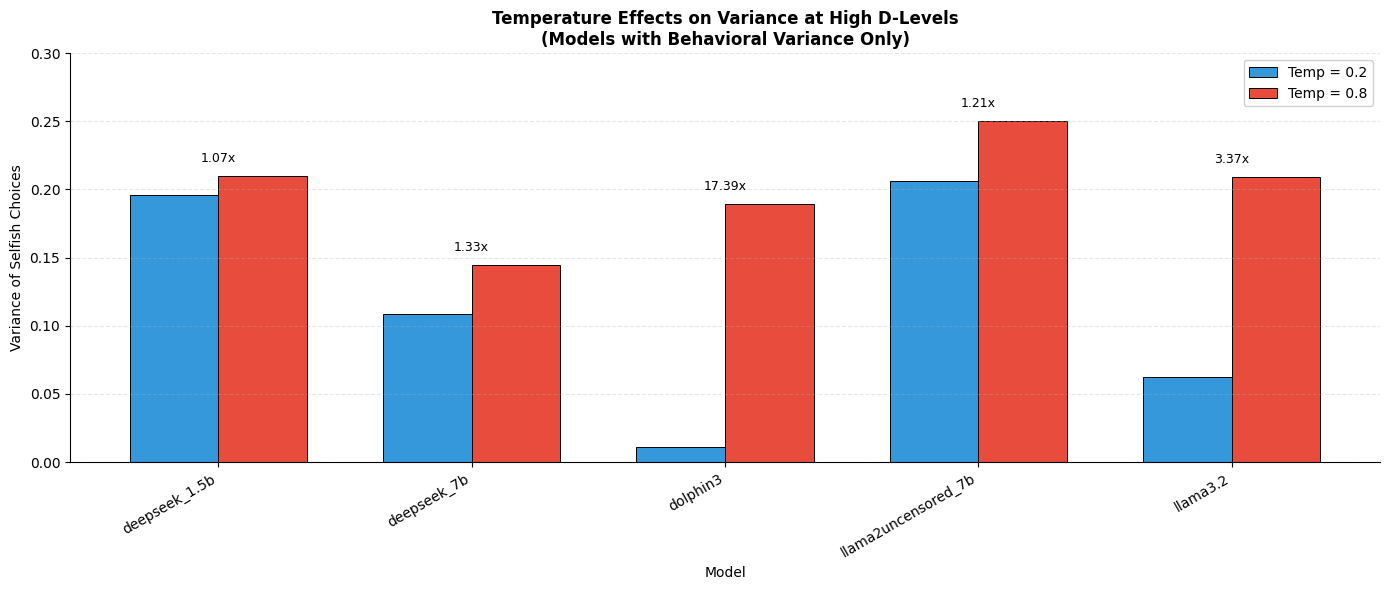

In [14]:
# Visualization: Per-model variance comparison
fig, ax = plt.subplots(figsize=(14, 6))

# Filter to variable models only for meaningful comparison
var_models_df = model_df[model_df['Type'] == 'Variable'].copy()

x = np.arange(len(var_models_df))
width = 0.35

bars1 = ax.bar(x - width/2, var_models_df['Var (0.2)'], width, 
               label='Temp = 0.2', color=COLOR_LOW_TEMP, edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + width/2, var_models_df['Var (0.8)'], width, 
               label='Temp = 0.8', color=COLOR_HIGH_TEMP, edgecolor='black', linewidth=0.7)

ax.set_xlabel('Model', fontweight='medium')
ax.set_ylabel('Variance of Selfish Choices', fontweight='medium')
ax.set_title('Temperature Effects on Variance at High D-Levels\n(Models with Behavioral Variance Only)', 
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(var_models_df['Model'], rotation=30, ha='right')
ax.legend(loc='upper right', framealpha=0.9)
ax.set_ylim(0, 0.30)
ax.yaxis.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add variance ratio annotations
for i, (_, row) in enumerate(var_models_df.iterrows()):
    if pd.notna(row['Var Ratio']):
        y_pos = max(row['Var (0.2)'], row['Var (0.8)']) + 0.01
        ax.annotate(f'{row["Var Ratio"]:.2f}x', xy=(i, y_pos), ha='center', fontsize=9)

plt.tight_layout()
#plt.savefig('temperature_variance_by_model.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. Analysis of Models with Behavioral Variance

In [15]:
# Focus on variable models only
var_subset = high_d[high_d['model'].isin(variable_models)]

print("ANALYSIS: MODELS WITH BEHAVIORAL VARIANCE ONLY")
print("="*60)
print(f"Models included: {variable_models}")
print(f"Total observations: {len(var_subset):,}")

lt = var_subset[var_subset['temperature'] == 0.2]['selfish']
ht = var_subset[var_subset['temperature'] == 0.8]['selfish']

print(f"\nTemperature 0.2:")
print(f"  Mean = {lt.mean():.4f}")
print(f"  Variance = {lt.var():.4f}")
print(f"  N = {len(lt):,}")

print(f"\nTemperature 0.8:")
print(f"  Mean = {ht.mean():.4f}")
print(f"  Variance = {ht.var():.4f}")
print(f"  N = {len(ht):,}")

var_ratio = ht.var() / lt.var()
print(f"\nVariance ratio (0.8 / 0.2): {var_ratio:.4f}")

# Tests
stat, p = stats.levene(lt, ht)
print(f"Levene's test: W = {stat:.2f}, p = {p:.6f}")

# Effect size
cohens_d = (ht.mean() - lt.mean()) / np.sqrt((lt.var() + ht.var()) / 2)
print(f"Cohen's d = {cohens_d:.4f}")

ANALYSIS: MODELS WITH BEHAVIORAL VARIANCE ONLY
Models included: ['deepseek_1.5b', 'deepseek_7b', 'dolphin3', 'llama2uncensored_7b', 'llama3.2']
Total observations: 19,997

Temperature 0.2:
  Mean = 0.3860
  Variance = 0.2370
  N = 10,000

Temperature 0.8:
  Mean = 0.4349
  Variance = 0.2458
  N = 9,997

Variance ratio (0.8 / 0.2): 1.0370
Levene's test: W = 49.58, p = 0.000000
Cohen's d = 0.0996


## 7. Responder Role Analysis

In [16]:
# Also check responder role for completeness
high_d_resp = resp[resp['d_num'] >= 4]

print("RESPONDER TEMPERATURE EFFECTS AT HIGH D-LEVELS")
print("="*60)

lt = high_d_resp[high_d_resp['temperature'] == 0.2]['prosocial']  # Accept rate
ht = high_d_resp[high_d_resp['temperature'] == 0.8]['prosocial']

print(f"\nAcceptance rates (prosocial behavior):")
print(f"  Temp 0.2: Mean={lt.mean():.4f}, Var={lt.var():.4f}, N={len(lt)}")
print(f"  Temp 0.8: Mean={ht.mean():.4f}, Var={ht.var():.4f}, N={len(ht)}")
print(f"  Variance ratio: {ht.var() / lt.var():.4f}")

stat, p = stats.levene(lt, ht)
print(f"  Levene's test: W = {stat:.2f}, p = {p:.6f}")

RESPONDER TEMPERATURE EFFECTS AT HIGH D-LEVELS

Acceptance rates (prosocial behavior):
  Temp 0.2: Mean=0.8006, Var=0.1596, N=34000
  Temp 0.8: Mean=0.8121, Var=0.1526, N=33975
  Variance ratio: 0.9559
  Levene's test: W = 14.35, p = 0.000152


### Appendix Table: Full Temperature Effects by D-Level

In [23]:
# Recompute with all statistics for appendix
appendix_rows = []
for d_level in [1, 2, 3, 4, 5]:
    d_names = {1: 'D1 (Low)', 2: 'D2 (Low-Moderate)', 3: 'D3 (Moderate)', 
               4: 'D4 (Moderate-High)', 5: 'D5 (High)'}
    
    subset = prop[prop['d_num'] == d_level]
    lt = subset[subset['temperature'] == 0.2]['selfish']
    ht = subset[subset['temperature'] == 0.8]['selfish']
    
    # Tests
    cont = pd.crosstab(subset['temperature'], subset['selfish'])
    chi2, p_chi = stats.chi2_contingency(cont)[:2]
    lev_stat, p_lev = stats.levene(lt, ht)
    
    appendix_rows.append({
        'D-Level': d_names[d_level],
        'N (temp=0.2)': len(lt),
        'N (temp=0.8)': len(ht),
        'Mean (0.2)': f'{lt.mean():.3f}',
        'Mean (0.8)': f'{ht.mean():.3f}',
        'SD (0.2)': f'{lt.std():.3f}',
        'SD (0.8)': f'{ht.std():.3f}',
        'Var (0.2)': f'{lt.var():.4f}',
        'Var (0.8)': f'{ht.var():.4f}',
        'Var Ratio': f'{ht.var()/lt.var():.3f}',
        'χ²': f'{chi2:.2f}',
        'p (χ²)': f'{p_chi:.4f}' if p_chi >= 0.0001 else '<.0001',
        'Levene W': f'{lev_stat:.2f}',
        'p (Levene)': f'{p_lev:.4f}' if p_lev >= 0.0001 else '<.0001'
    })

appendix_table_a = pd.DataFrame(appendix_rows)

print("APPENDIX TABLE A: Temperature Effects on Selfish Choices by D-Level")
print("="*100)
print(appendix_table_a.to_string(index=False))

APPENDIX TABLE A: Temperature Effects on Selfish Choices by D-Level
           D-Level  N (temp=0.2)  N (temp=0.8) Mean (0.2) Mean (0.8) SD (0.2) SD (0.8) Var (0.2) Var (0.8) Var Ratio    χ² p (χ²) Levene W p (Levene)
          D1 (Low)         17000         16994      0.096      0.079    0.295    0.269    0.0872    0.0724     0.830 33.93 <.0001    34.18     <.0001
 D2 (Low-Moderate)         17000         16995      0.226      0.228    0.418    0.419    0.1748    0.1758     1.006  0.17 0.6772     0.18     0.6678
     D3 (Moderate)         17000         16995      0.580      0.576    0.494    0.494    0.2436    0.2442     1.002  0.44 0.5092     0.45     0.5022
D4 (Moderate-High)         17000         16997      0.813      0.828    0.390    0.377    0.1517    0.1422     0.937 12.75 0.0004    12.86     0.0003
         D5 (High)         17000         17000      0.825      0.839    0.380    0.367    0.1442    0.1349     0.936 11.73 0.0006    11.84     0.0006


### Appendix Table: Per-Model Temperature Effects at High D-Levels

In [22]:
high_d = prop[prop['d_num'] >= 4]

appendix_model_rows = []
for model in sorted(prop['model'].unique()):
    subset = high_d[high_d['model'] == model]
    lt = subset[subset['temperature'] == 0.2]['selfish']
    ht = subset[subset['temperature'] == 0.8]['selfish']
    
    if len(lt) >= 50 and len(ht) >= 50:
        # Determine model type
        overall_var = subset['selfish'].var()
        model_type = 'Variable' if overall_var > 0.01 else 'Ceiling'
        
        # Variance ratio
        var_ratio = ht.var() / lt.var() if lt.var() > 0.001 else None
        
        # Levene test
        try:
            lev_stat, p_lev = stats.levene(lt, ht)
        except:
            lev_stat, p_lev = None, None
        
        appendix_model_rows.append({
            'Model': model,
            'Type': model_type,
            'N (0.2)': len(lt),
            'N (0.8)': len(ht),
            'Mean (0.2)': f'{lt.mean():.3f}',
            'Mean (0.8)': f'{ht.mean():.3f}',
            'Var (0.2)': f'{lt.var():.4f}',
            'Var (0.8)': f'{ht.var():.4f}',
            'Var Ratio': f'{var_ratio:.2f}' if var_ratio else 'N/A',
            'Levene W': f'{lev_stat:.2f}' if lev_stat else 'N/A',
            'p': f'{p_lev:.4f}' if p_lev and p_lev >= 0.0001 else '<.0001' if p_lev else 'N/A'
        })

appendix_table_b = pd.DataFrame(appendix_model_rows)

print("APPENDIX TABLE B: Per-Model Temperature Effects at High D-Levels (D4 & D5)")
print("="*110)
print(appendix_table_b.to_string(index=False))

# Summary counts
n_ceiling = len(appendix_table_b[appendix_table_b['Type'] == 'Ceiling'])
n_variable = len(appendix_table_b[appendix_table_b['Type'] == 'Variable'])
print(f"\nSummary: {n_ceiling} models at ceiling, {n_variable} models with behavioral variance")

APPENDIX TABLE B: Per-Model Temperature Effects at High D-Levels (D4 & D5)
              Model     Type  N (0.2)  N (0.8) Mean (0.2) Mean (0.8) Var (0.2) Var (0.8) Var Ratio Levene W      p
      deepseek_1.5b Variable     2000     2000      0.267      0.300    0.1956    0.2101      1.07     5.53 0.0187
        deepseek_7b Variable     2000     2000      0.876      0.825    0.1087    0.1448      1.33    20.93 <.0001
           dolphin3 Variable     2000     2000      0.011      0.254    0.0109    0.1893     17.39   587.43 <.0001
         gemma3_12b  Ceiling     2000     2000      1.000      1.000    0.0000    0.0000       N/A      nan <.0001
          gemma3_1b  Ceiling     2000     2000      1.000      1.000    0.0000    0.0000       N/A      nan <.0001
          gemma3_4b  Ceiling     2000     2000      1.000      1.000    0.0000    0.0000       N/A      nan <.0001
        gemma3n_e2b  Ceiling     2000     2000      1.000      1.000    0.0000    0.0000       N/A      nan <.0001
     

In [39]:
print("="*70)
print("NOTEBOOK COMPLETE - FILES GENERATED")
print("="*70)
print("""
MAIN TEXT:
  • Figures/temperature_maintext_figure.png (.pdf)

APPENDIX:
  • appendix_table_a_temperature_by_dlevel.csv
  • appendix_table_b_temperature_by_model.csv  
  • Figures/appendix_temperature_analysis.png (.pdf)
  • Figures/appendix_model_type_comparison.png (.pdf)

OTHER:
  • temperature_effects_by_dlevel.csv
  • temperature_effects_by_model.csv
  • Figures/temperature_effects_by_dlevel.png (.pdf)
  • Figures/temperature_variance_by_model.png (.pdf)
  • Figures/temperature_analysis_summary.png (.pdf)
""")

NOTEBOOK COMPLETE - FILES GENERATED

MAIN TEXT:
  • Figures/temperature_maintext_figure.png (.pdf)

APPENDIX:
  • appendix_table_a_temperature_by_dlevel.csv
  • appendix_table_b_temperature_by_model.csv  
  • Figures/appendix_temperature_analysis.png (.pdf)
  • Figures/appendix_model_type_comparison.png (.pdf)

OTHER:
  • temperature_effects_by_dlevel.csv
  • temperature_effects_by_model.csv
  • Figures/temperature_effects_by_dlevel.png (.pdf)
  • Figures/temperature_variance_by_model.png (.pdf)
  • Figures/temperature_analysis_summary.png (.pdf)

